# 01 — Data Profiling: Sparkify Raw Data

**Goal (GUIDELINE Step 3):** understand the raw JSON *before* building anything on AWS, so that the data model,
Redshift design and data-quality checks are based on evidence.

Questions this notebook answers:
1. What fields exist, what types are they, and where are the NULLs?
2. What does an "event" look like (`page`, `userId`, `ts`, `level`)?
3. How well do log events match the song catalog (**song match rate**)?
4. Is there enough data to answer our 5 business questions (BQ1–BQ5)?

Data source: `data/raw/` (download with `python3 scripts/download_dataset.py`).

In [1]:
import glob, json, os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})

RAW = "../data/raw"
FIG = "../docs/figures"
os.makedirs(FIG, exist_ok=True)

## 1. Load the data

In [2]:
song_files = glob.glob(f"{RAW}/song_data/**/*.json", recursive=True)
log_files = sorted(glob.glob(f"{RAW}/log_data/**/*.json", recursive=True))

songs = pd.DataFrame([json.load(open(f)) for f in song_files])
logs = pd.concat([pd.read_json(f, lines=True, dtype={"userId": str}) for f in log_files], ignore_index=True)

print(f"song_data: {len(song_files):,} files -> {len(songs):,} rows")
print(f"log_data : {len(log_files):,} files -> {len(logs):,} rows")

song_data: 14,896 files -> 14,896 rows
log_data : 30 files -> 8,056 rows


## 2. Song data (`song_data`)

In [3]:
songs.head()

,artist_id,artist_latitude,artist_location,artist_longitude,artist_name,duration,num_songs,song_id,title,year
0,AR052WY1187FB55B1C,27.49550,BRADENTON. FL,-82.57807,We The Kings,194.35057,1,SOGEKSP12A58A78530,August Is Over,2007
1,AR0S3YD1187B99967F,NaN,"Jacksonville, FL",NaN,The Classics IV,127.65995,1,SOYRACV12A8C13C4D8,24 Hours Of Loneliness,1975
2,ARNNRN31187B9AE7B7,NaN,"Forrest City, AR",NaN,Al Green,189.41342,1,SOIDBNB12A58A7A72C,Keep Me Crying,1976
3,ARZDP5D1187B9B4ECB,50.84838,Brussel 1981,4.34968,Arbeid Adelt!,279.03955,1,SOEDXTY12A6D4FB0ED,Het Meisje Van Mijn Hart,1983
4,ARFL99B1187B9A2A45,NaN,"PERTH AMBOY, New Jersey",NaN,Sugarland,202.26567,1,SOXTCXD12AB0183E39,Silent Night,2009


In [4]:
song_profile = pd.DataFrame({
    "dtype": songs.dtypes.astype(str),
    "nulls": songs.isna().sum(),
    "empty_string": (songs == "").sum(),
    "distinct": songs.nunique(),
})
song_profile

,dtype,nulls,empty_string,distinct
artist_id,str,0,0,9553
artist_latitude,float64,9619,0,1109
artist_location,object,1,6694,2084
artist_longitude,float64,9619,0,1110
artist_name,object,0,0,9936
duration,float64,0,0,8460
num_songs,int64,0,0,1
song_id,str,0,0,14896
title,object,0,0,14402
year,int64,0,0,60


In [5]:
checks = {
    "rows": len(songs),
    "duplicate song_id": songs.song_id.duplicated().sum(),
    "year = 0 (unknown year)": (songs.year == 0).sum(),
    "artist_latitude NULL": songs.artist_latitude.isna().sum(),
    "distinct artist_id": songs.artist_id.nunique(),
    "artist_id with >1 artist_name": (songs.groupby("artist_id").artist_name.nunique() > 1).sum(),
}
pd.Series(checks, name="value").to_frame()

,value
rows,14896
duplicate song_id,0
year = 0 (unknown year),4762
artist_latitude NULL,9619
distinct artist_id,9553
artist_id with >1 artist_name,396


Example of one `artist_id` that maps to several `artist_name` values (usually featured artists / collaborations).
This means `dim_artists` **cannot** be built with a plain `SELECT DISTINCT artist_id, artist_name` — it would create duplicate keys.

In [6]:
multi = songs.groupby("artist_id").artist_name.nunique().sort_values(ascending=False)
songs[songs.artist_id == multi.index[0]][["artist_id", "artist_name", "title"]].head(8)

,artist_id,artist_name,title
6312,ARMD3XX1187B9ACF84,Cypress Hill featuring Prodigy and Twin,Last Laugh
6437,ARMD3XX1187B9ACF84,Cypress Hill,How I Could Just Kill A Man
10196,ARMD3XX1187B9ACF84,Cypress Hill featuring Kurupt,Kronologik
10335,ARMD3XX1187B9ACF84,Cypress Hill featuring M.C. Ren & King Tee,Southland Killers


## 3. Event logs (`log_data`)

In [7]:
logs.head()

,artist,auth,firstName,gender,itemInSession,lastName,length,level,location,method,page,registration,sessionId,song,status,ts,userAgent,userId
0,NaN,Logged In,Walter,M,0,Frye,NaN,free,"San Francisco-Oakland-Hayward, CA",GET,Home,1.540919e+12,38,NaN,200,1541105830796,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",39
1,NaN,Logged In,Kaylee,F,0,Summers,NaN,free,"Phoenix-Mesa-Scottsdale, AZ",GET,Home,1.540345e+12,139,NaN,200,1541106106796,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",8
2,Des'ree,Logged In,Kaylee,F,1,Summers,246.30812,free,"Phoenix-Mesa-Scottsdale, AZ",PUT,NextSong,1.540345e+12,139,You Gotta Be,200,1541106106796,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",8
3,NaN,Logged In,Kaylee,F,2,Summers,NaN,free,"Phoenix-Mesa-Scottsdale, AZ",GET,Upgrade,1.540345e+12,139,NaN,200,1541106132796,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",8
4,Mr Oizo,Logged In,Kaylee,F,3,Summers,144.03873,free,"Phoenix-Mesa-Scottsdale, AZ",PUT,NextSong,1.540345e+12,139,Flat 55,200,1541106352796,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",8


In [8]:
log_profile = pd.DataFrame({
    "dtype": logs.dtypes.astype(str),
    "nulls": logs.isna().sum(),
    "empty_string": (logs.astype(str) == "").sum(),
    "distinct": logs.nunique(),
})
log_profile

,dtype,nulls,empty_string,distinct
artist,str,1236,0,3148
auth,str,0,0,2
firstName,str,286,0,85
gender,str,286,0,2
itemInSession,int64,0,0,128
lastName,str,286,0,87
length,float64,1236,0,3994
level,str,0,0,2
location,str,286,0,63
method,str,0,0,2


### 3.1 Page types

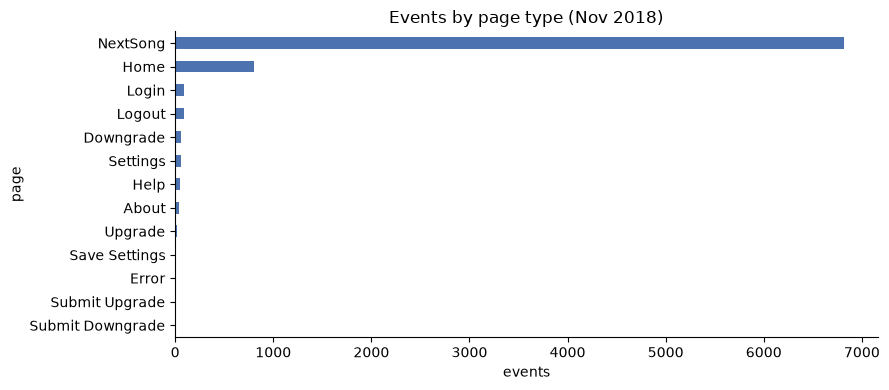

,events
page,
NextSong,6820
Home,806
Login,92
Logout,90
Downgrade,60
Settings,56
Help,47
About,36
Upgrade,21


In [9]:
page_counts = logs.page.value_counts()
ax = page_counts.sort_values().plot.barh(color="#4C72B0")
ax.set_title("Events by page type (Nov 2018)")
ax.set_xlabel("events")
plt.tight_layout(); plt.savefig(f"{FIG}/profiling_page_counts.png", dpi=150); plt.show()
page_counts.to_frame("events")

Only `NextSong` events are song plays (the grain of `fact_songplays`). The other pages — especially
`Upgrade`, `Submit Upgrade`, `Downgrade`, `Submit Downgrade` — are needed for **BQ3 (upgrade funnel)** and
**BQ4 (churn risk)**, so we keep them in a second fact table `fact_page_events`.

### 3.2 Events without `userId` (logged-out users)

In [10]:
no_user = logs[logs.userId == ""]
print(f"events with empty userId: {len(no_user):,} ({len(no_user)/len(logs):.1%})")
no_user.groupby(["auth", "page"]).size().to_frame("events")

events with empty userId: 286 (3.6%)


events
auth       page         
Logged Out About      14
           Help        9
           Home      171
           Login      92

Empty `userId` only appears on logged-out pages (Home, Login, About, Help) — never on `NextSong`. These rows must be excluded from user-level analysis.

### 3.3 Timestamp (`ts`)

In [11]:
logs["start_time"] = pd.to_datetime(logs.ts, unit="ms")
print("ts is epoch milliseconds (UTC)")
print("first event:", logs.start_time.min())
print("last event :", logs.start_time.max())

ts is epoch milliseconds (UTC)
first event: 2018-11-01 20:57:10.796000
last event : 2018-11-30 19:54:24.796000


### 3.4 Users and subscription level

In [12]:
users = logs[logs.userId != ""]
summary = {
    "distinct users": users.userId.nunique(),
    "distinct sessions": logs.sessionId.nunique(),
    "song plays (NextSong)": (logs.page == "NextSong").sum(),
    "users seen with BOTH free and paid": (users.groupby("userId")["level"].nunique() == 2).sum(),
}
pd.Series(summary, name="value").to_frame()

,value
distinct users,97
distinct sessions,941
song plays (NextSong),6820
users seen with BOTH free and paid,8


Some users change level during the month. `dim_users` in the reference README keeps only one value per user,
so we must decide which one to keep (the **latest** event) — or model history with SCD Type 2 (optional ⭐).

## 4. Song match rate

`fact_songplays.song_id` / `artist_id` come from joining events to the song catalog on title + artist (+ duration).
We test three matching rules locally to know the match rate before loading to Redshift.

In [13]:
plays = logs[logs.page == "NextSong"]
rules = {
    "title + artist + duration (exact)": ["song", "artist", "length"],
    "title + artist": ["song", "artist"],
}
right = {"song": "title", "artist": "artist_name", "length": "duration"}
rows = []
for name, keys in rules.items():
    matched = plays.merge(songs.drop_duplicates([right[k] for k in keys]),
                          left_on=keys, right_on=[right[k] for k in keys], how="inner")
    rows.append({"rule": name, "matched plays": len(matched), "total plays": len(plays),
                 "match rate": f"{len(matched)/len(plays):.1%}"})
match_rate = pd.DataFrame(rows)
match_rate

,rule,matched plays,total plays,match rate
0,title + artist + duration (exact),319,6820,4.7%
1,title + artist,333,6820,4.9%


**Finding:** only a small share of plays match the catalog because `song_data` is a small subset of the
Million Song Dataset. Consequences for our design:

- Most rows in `fact_songplays` will have `song_id` / `artist_id` = NULL → **do not use `DISTKEY(song_id)`**
  (all NULLs would hash to one slice → data skew). Use `DISTSTYLE AUTO`/`EVEN` instead.
- Top-artist / top-song charts must be based on the raw `artist` / `song` text in the event, or clearly labelled as "matched songs only".
- Song match rate becomes a reported **data-quality metric**.

## 5. Can the data answer our business questions?

### BQ1 — Peak listening hours and days

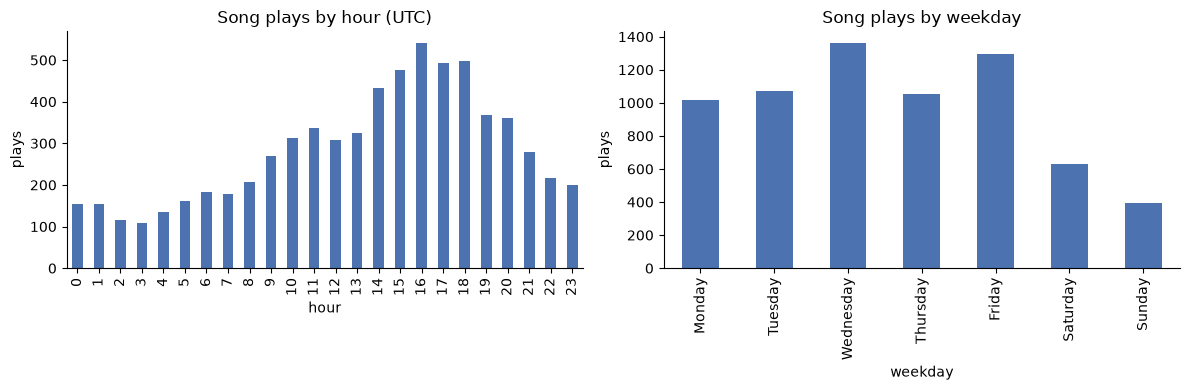

In [14]:
plays = plays.assign(hour=plays.start_time.dt.hour, weekday=plays.start_time.dt.day_name())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plays.groupby("hour").size().plot.bar(ax=axes[0], color="#4C72B0", title="Song plays by hour (UTC)")
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plays.weekday.value_counts().reindex(order).plot.bar(ax=axes[1], color="#4C72B0", title="Song plays by weekday")
for a in axes: a.set_ylabel("plays")
plt.tight_layout(); plt.savefig(f"{FIG}/profiling_bq1_hour_weekday.png", dpi=150); plt.show()

### BQ2 — Free vs paid engagement

In [15]:
per_session = plays.groupby(["level", "sessionId"]).size().rename("songs").reset_index()
per_session.groupby("level").songs.agg(sessions="count", avg_songs_per_session="mean", median="median").round(1)

,sessions,avg_songs_per_session,median
level,,,
free,587,2.1,2.0
paid,197,28.4,19.0


### BQ3 — Upgrade funnel

In [16]:
funnel_pages = ["Upgrade", "Submit Upgrade"]
funnel = users[users.page.isin(funnel_pages)].groupby("page").agg(events=("ts", "size"), users=("userId", "nunique"))
funnel.reindex(funnel_pages)

,events,users
page,,
Upgrade,21,15
Submit Upgrade,8,8


### BQ4 — Churn risk (Downgrade page)

In [17]:
down_pages = ["Downgrade", "Submit Downgrade"]
users[users.page.isin(down_pages)].groupby(["page", "level"]).agg(events=("ts", "size"), users=("userId", "nunique"))

,,events,users
page,level,,
Downgrade,paid,60,17
Submit Downgrade,paid,1,1


### BQ5 — Paid ratio by state

In [18]:
latest = users.sort_values("ts").groupby("userId").tail(1)        # latest known level per user
latest = latest.assign(state=latest.location.str.split(", ").str[-1])
by_state = (latest.groupby("state")
            .agg(users=("userId", "nunique"), paid_users=("level", lambda s: (s == "paid").sum())))
by_state["paid_ratio"] = (by_state.paid_users / by_state.users).round(2)
by_state.sort_values(["users", "paid_ratio"], ascending=False).head(10)

,users,paid_users,paid_ratio
state,,,
CA,17,4,0.24
TX,13,2,0.15
NY-NJ-PA,10,2,0.20
MI,4,2,0.50
FL,4,1,0.25
GA,3,2,0.67
AZ,3,1,0.33
IL-IN-WI,3,1,0.33
IN,3,0,0.00


`location` looks like `"San Francisco-Oakland-Hayward, CA"` → state is the text after the last comma. Some are multi-state metro areas (e.g. `IL-IN-WI`), which we keep as-is.

### Overview chart — BQ2 to BQ5

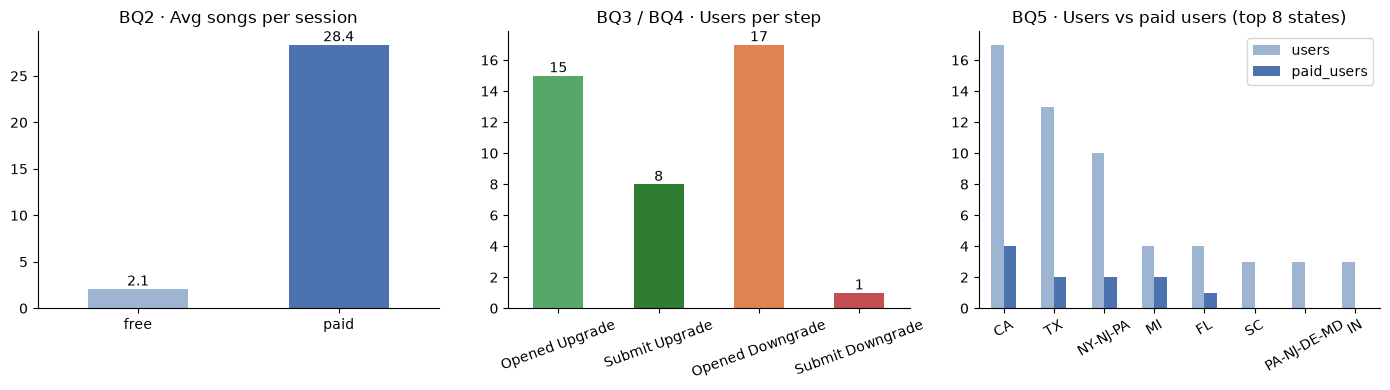

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bq2 = per_session.groupby("level").songs.mean().reindex(["free", "paid"])
bq2.plot.bar(ax=axes[0], color=["#9DB4D3", "#4C72B0"], rot=0, title="BQ2 · Avg songs per session")
for i, v in enumerate(bq2): axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom")
steps = pd.Series({
    "Opened Upgrade": users[users.page == "Upgrade"].userId.nunique(),
    "Submit Upgrade": users[users.page == "Submit Upgrade"].userId.nunique(),
    "Opened Downgrade": users[users.page == "Downgrade"].userId.nunique(),
    "Submit Downgrade": users[users.page == "Submit Downgrade"].userId.nunique(),
})
steps.plot.bar(ax=axes[1], color=["#55A868", "#2E7D32", "#DD8452", "#C44E52"], rot=20, title="BQ3 / BQ4 · Users per step")
for i, v in enumerate(steps): axes[1].text(i, v, str(v), ha="center", va="bottom")
top = by_state.sort_values("users", ascending=False).head(8)
top[["users", "paid_users"]].plot.bar(ax=axes[2], color=["#9DB4D3", "#4C72B0"], rot=30, title="BQ5 · Users vs paid users (top 8 states)")
for a in axes: a.set_xlabel("")
plt.tight_layout(); plt.savefig(f"{FIG}/profiling_bq2_to_bq5.png", dpi=150); plt.show()

## 6. Summary of findings

| # | Finding | Impact on the design |
|---|---|---|
| 1 | 8,056 events / 6,820 song plays / 97 users / 941 sessions, all in **Nov 2018** | Sample data only — the report must state that the system is designed to scale beyond it |
| 2 | `ts` is epoch **milliseconds** (UTC) | Convert with `TIMESTAMP 'epoch' + ts/1000 * INTERVAL '1 second'` in Redshift |
| 3 | 286 events (3.6%) have empty `userId` — all logged-out pages, never `NextSong` | Filter `userId <> ''` before loading user-level tables |
| 4 | 8 users switch between free and paid during the month | `dim_users.level` = latest event (or SCD Type 2 ⭐) |
| 5 | **Song match rate ≈ 4.7%** (319 / 6,820 plays) | Do **not** use `DISTKEY(song_id)` on the fact; report match rate as a DQ metric |
| 6 | 396 `artist_id`s have more than one `artist_name` (e.g. "X featuring Y") | Deduplicate `dim_artists` (one row per `artist_id`) + DQ check for duplicate keys |
| 7 | `song_data.year = 0` for 4,762 songs (32%); `artist_location` is empty for 6,694; lat/long NULL for 9,619 | Store `year = 0` as NULL; location/lat/long are optional attributes |
| 8 | BQ1: peak at **16:00–18:00 UTC**, lowest at 02:00–04:00; weekdays ≫ weekends | Data is sufficient |
| 9 | BQ2: paid sessions average **28.4** songs vs **2.1** for free | Data is sufficient — strong business story |
| 10 | BQ3: 15 users opened Upgrade → 8 submitted (≈53%) | Needs `fact_page_events`; small numbers, interpret carefully |
| 11 | BQ4: 17 paid users opened Downgrade, only 1 submitted | Needs `fact_page_events`; good "early warning" signal |
| 12 | BQ5: 22 paid / 75 free users (latest level); most states have < 5 users | Show counts next to ratios so small samples are not over-interpreted |